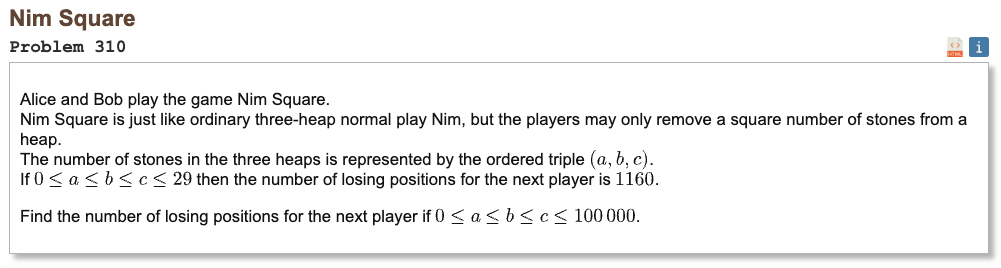

## Initial approach

* calculate the game value for every heap size up to the limit
* each move removes a square number of stones
* a heap value depends on the values reachable after one legal move
* a three-heap position is losing when the three heap values cancel out
* count how many heap sizes have each game value
* first count ordered triples using those frequencies
* convert the ordered count into the required nondecreasing triples
* verify the method with the small example before using the large limit

In [1]:
from collections import Counter
import math

def build_grundy(limit):
    squares = [i * i for i in range(1, math.isqrt(limit) + 1)]
    grundy = [0] * (limit + 1)

    seen = [0] * 512
    stamp = 0

    for n in range(1, limit + 1):
        stamp += 1

        for s in squares:
            if s > n:
                break
            seen[grundy[n - s]] = stamp

        g = 0
        while seen[g] == stamp:
            g += 1

        grundy[n] = g

    return grundy

def solve(limit):
    grundy = build_grundy(limit)
    counts = Counter(grundy)

    ordered_total = 0

    for a, ca in counts.items():
        for b, cb in counts.items():
            c = a ^ b
            ordered_total += ca * cb * counts.get(c, 0)

    all_equal = counts[0]
    two_equal = limit * counts[0]

    result = (ordered_total + 3 * two_equal + 5 * all_equal) // 6

    return result

assert solve(29) == 1160

In [2]:
%%time
result = solve(100000)
print("Result:", result)

Result: 2586528661783
CPU times: user 605 ms, sys: 7.64 ms, total: 613 ms
Wall time: 621 ms
